# Detrend and high-pass filter standardized time series

This is the treatment companion to [Standardize Time Axes](1_setup__standardize_time_axes.ipynb): it assumes that
notebook has already written decadal, common-time-axis real series to the project's master directories.

Both treatments tackle the same worry raised in Discussion and Text S2.2: CCM is a pattern-matching method, and slow secular trends or long-period macrostructure (like the residual insolation/deglaciation drift some Greenland records carry) can make unrelated snippets look artificially similar or artificially distinct, inflating or deflating apparent causal skill for reasons other than real TSI influence.

- **Linear detrending** (`pyleoclim.utils.tsutils.detrend`) removes any linear trend; while several records are already stationary (or close), e.g., ALLEY00, Seierstad14 GISP2, in other cases this detrending step removes confounding macrostructure (e.g., Döring22 GISP2, Seierstad14 NGRIP δ¹⁸O).
- **1-kyr high-pass filtering** (`pyleoclim.utils.filter.firwin`) guards against a  different worry: long-period insolation variability could inflate temperature predictability independently of TSI, and the climate response to TSI should  mostly play out on sub-millennial timescales anyway. But genuine solar cycles as long as the ~2,400 yr Hallstatt cycle do exist, so the high-pass results are a conservative *lower bound* on the evidence for influence rather than a more "correct" version of the analysis.

The two treatments run independently of each other, the high-pass filter starts from the raw series rather than the detrended one, and both get applied to the real data. Surrogates are generated from the treated time series. Nothing is written automatically; review the resulting objects and the visual check below, then explicitly uncomment the save cells at the end. The visual check plots one variable at a time on demand; the full multi-record comparison across all treatments (Fig. S5) is assembled in [Raw Data & Power Spectra (Figures 1 & S5)](3_plot__Fig1_real_ts_psd_unified.ipynb).

**ALERT**: It is exceptionally rare that a treatment removes a truly secular and known trend from an observational time series. Any treatment changes local temporal structure (viz. which snippets look alike (for more on this check out [Choosing E and τ (Figure S1)](../1_Embedding/1_plot__FigS1_embedding.ipynb)) and therefore how one time series will relate to another.

## Imports and project locations

In [11]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyleoclim as pyleo
from cedarkit.core.data_var import VarObject

stem = Path(*(p := Path.cwd().resolve()).parts[: p.parts.index("notebooks")])
PROJECT_ROOT = stem / 'hol_temp_tsi_ccm'


## Configured treatment names

Each raw variable's linear-detrended and 1-kyr high-pass counterparts are the same
variable IDs already established across the book (see the flat `var_ids` list in
[Raw Data & Power Spectra (Figures 1 & S5)](3_plot__Fig1_real_ts_psd_unified.ipynb).

In [12]:
TREATMENT_CONFIG_IDS = {
    'Erb22daGMST': {'linear': 'Erb22daGMSTLinear', 'highpass': 'erb22dagmst1kyrfir'},
    'Wu18TSI': {'linear': 'Wu18TSILinear', 'highpass': 'wu18tsianom1kyrfir'},
    'Vieira11TSI': {'linear': 'Vieira11TSILinear', 'highpass': 'vieira11tsianom1kyrfir'},
    'GISP2Alley00Tanom': {'linear': 'GISP2Alley00TanomLinear', 'highpass': 'alley00gisp2multiproxy1kyrfir'},
    'Tian22HT115kaALLGMST': {'linear': 'Tian22HT115kaALLGMSTLinear', 'highpass': 'tian22ht115kaallgmst1kyrfir'},
    'GISP2Doering22T15N': {'linear': 'GISP2Doering22T15NLinear', 'highpass': 'doering22gisp2t15n1kyrfir'},
    'GISP2Martin24Tanom': {'linear': 'GISP2Martin24TanomLinear', 'highpass': 'martin24gisp2tanom1kyrfir'},
    'NGRIPMartin24Tanom': {'linear': 'NGRIPMartin24TanomLinear', 'highpass': 'martin24ngriptanom1kyrfir'},
    'GISP2Seierstad14d18O': {'linear': 'GISP2Seierstad14d18OLinear', 'highpass': 'seierstad14gisp2d18o1kyrfir'},
    'NGRIP1Seierstad14d18O': {'linear': 'NGRIP1Seierstad14d18OLinear', 'highpass': 'seierstad14ngrip1d18o1kyrfir'},
}

pd.DataFrame.from_dict(TREATMENT_CONFIG_IDS, orient='index')

,linear,highpass
Erb22daGMST,Erb22daGMSTLinear,erb22dagmst1kyrfir
Wu18TSI,Wu18TSILinear,wu18tsianom1kyrfir
Vieira11TSI,Vieira11TSILinear,vieira11tsianom1kyrfir
GISP2Alley00Tanom,GISP2Alley00TanomLinear,alley00gisp2multiproxy1kyrfir
Tian22HT115kaALLGMST,Tian22HT115kaALLGMSTLinear,tian22ht115kaallgmst1kyrfir
GISP2Doering22T15N,GISP2Doering22T15NLinear,doering22gisp2t15n1kyrfir
GISP2Martin24Tanom,GISP2Martin24TanomLinear,martin24gisp2tanom1kyrfir
NGRIPMartin24Tanom,NGRIPMartin24TanomLinear,martin24ngriptanom1kyrfir
GISP2Seierstad14d18O,GISP2Seierstad14d18OLinear,seierstad14gisp2d18o1kyrfir
NGRIP1Seierstad14d18O,NGRIP1Seierstad14d18OLinear,seierstad14ngrip1d18o1kyrfir


## Treatment helpers

The functions below operate on a source that has already been read into a `VarObject`. High-pass filtering uses a 1,000-year lower edge and 99% of Nyquist as the upper edge.

In [13]:
def csv_path(directory, csv_stem):
    """Return a CSV path whether the configured name includes `.csv` or not."""
    path = Path(directory) / str(csv_stem)
    return path if path.suffix.lower() == '.csv' else path.with_suffix('.csv')


def load_real_var_object(var_id):
    """Load a non-empty standardized real series into its configured VarObject."""
    var_object = VarObject(None, var_id, PROJECT_ROOT)
    source_path = csv_path(var_object.real_data_dir_path, var_object.real_ts_csv)
    if not source_path.exists() or source_path.stat().st_size == 0:
        raise FileNotFoundError(f'{var_id} is not ready at {source_path}.')
    var_object.get_real()
    if not hasattr(var_object, 'ts') or var_object.ts.empty:
        raise ValueError(f'{var_id} did not load a usable time series from {source_path}.')
    return var_object


def attach_real_series(var_object, time, values):
    """Attach processed values using the target YAML's configured column names."""
    var_object.ts_type = 'real'
    var_object.set_col_name()
    var_object.time_var = var_object.real_ts_time
    var_object.ts = pd.DataFrame({
        var_object.time_var: np.asarray(time),
        var_object.col_name: np.asarray(values),
    })
    return var_object


def linear_detrend_values(values, time):
    """Return Pyleoclim linear-detrended values and the fitted linear trend."""
    return pyleo.utils.tsutils.detrend(
        np.asarray(values, dtype=float), x=np.asarray(time, dtype=float),
        method='linear', sg_kwargs=None,
    )


def fir_highpass_values(values, time, period_years=1_000):
    """Apply the reference 1 kyr FIR high-pass filter to a regular series."""
    dt_years = np.median(np.diff(np.asarray(time, dtype=float)))
    sampling_frequency = 1 / dt_years
    return pyleo.utils.filter.firwin(
        np.asarray(values, dtype=float),
        fc=np.array([1 / period_years, 0.99 * 0.5 * sampling_frequency]),
        fs=sampling_frequency, pad='reflect',
    )


def make_treated_real_object(source_object, target_var_id, treatment):
    """Transform one loaded raw object and attach it to a target-config object."""
    target_object = VarObject(None, target_var_id, PROJECT_ROOT)
    time = source_object.ts[source_object.time_var].to_numpy()
    values = source_object.ts[source_object.col_name].to_numpy()
    if treatment == 'linear':
        treated_values, trend = linear_detrend_values(values, time)
    elif treatment == 'highpass':
        treated_values = fir_highpass_values(values, time)
        trend = None
    else:
        raise ValueError(f'Unknown treatment: {treatment}')
    return attach_real_series(target_object, time, treated_values), trend

## Create treated real-series objects

Any raw variable whose standardized CSV isn't ready yet is skipped with a printed
note, rather than stopping the whole loop. The high-pass branch starts from the raw
standardized series, not the detrended one, matching the earlier filter workflow.

In [14]:

raw_var_objects = {}
linear_var_objects = {}
highpass_var_objects = {}
linear_trends = {}

for raw_var_id, target_ids in TREATMENT_CONFIG_IDS.items():
    try:
        raw_object = load_real_var_object(raw_var_id)
    except (FileNotFoundError, ValueError) as error:
        print(f'Skipping {raw_var_id}: {error}')
        continue
    raw_var_objects[raw_var_id] = raw_object

    linear_object, fitted_trend = make_treated_real_object(
        raw_object, target_ids['linear'], treatment='linear'
    )
    highpass_object, _ = make_treated_real_object(
        raw_object, target_ids['highpass'], treatment='highpass'
    )
    linear_var_objects[raw_var_id] = linear_object
    highpass_var_objects[raw_var_id] = highpass_object
    linear_trends[raw_var_id] = fitted_trend


filtering with windown hamming
filtering with windown hamming
filtering with windown hamming
filtering with windown hamming
filtering with windown hamming
filtering with windown hamming
filtering with windown hamming
filtering with windown hamming
filtering with windown hamming
filtering with windown hamming


## Figure palette

Same source/treatment color scheme as Fig. S5 ([Raw Data & Power Spectra (Figures 1 & S5)](3_plot__Fig1_real_ts_psd_unified.ipynb)), so a variable's treated colors here match how it appears there.

In [15]:
palette_var_groups = {
    "GMST": ["tian22ht115kaallgmst", "erb22dagmst"],
    "temp": ["alley00gisp2multiproxy", "gisp2alley00tanom", "doering22gisp2t15n", "gisp2doering22t15n", "martin24gisp2tanom", "gisp2martin24tanom", "martin24ngriptanom", "ngripmartin24tanom"],
    "d18O": ["seierstad14gisp2d18o", "gisp2seierstad14d18o", "seierstad14ngrip1d18o", "ngrip1seierstad14d18o"],
    "TSI": ["wu18tsianom", "wu18tsi", "vieira11tsianom", "vieira11tsi"],
}

group_palette_triples = {
    "GMST": {"raw": "xkcd:orange", "linearlydetrended": "xkcd:raspberry", "1kyr": "xkcd:plum"},
    "temp": {"raw": "xkcd:navy blue", "linearlydetrended": "xkcd:cornflower blue", "1kyr": "xkcd:sea blue"},
    "d18O": {"raw": "xkcd:twilight blue", "linearlydetrended": "xkcd:dark teal", "1kyr": "xkcd:jungle green"},
    "TSI": {"raw": "xkcd:orangeish", "linearlydetrended": "xkcd:goldenrod", "1kyr": "xkcd:dark maroon"},
}

source_to_group = {
    source_key: group_name
    for group_name, source_keys in palette_var_groups.items()
    for source_key in source_keys
}


## Visual check

The comparison uses one selected treatment family. The fitted linear trend is shown on the raw axis, while the two transformed products retain the same Wu-centred decadal dates.

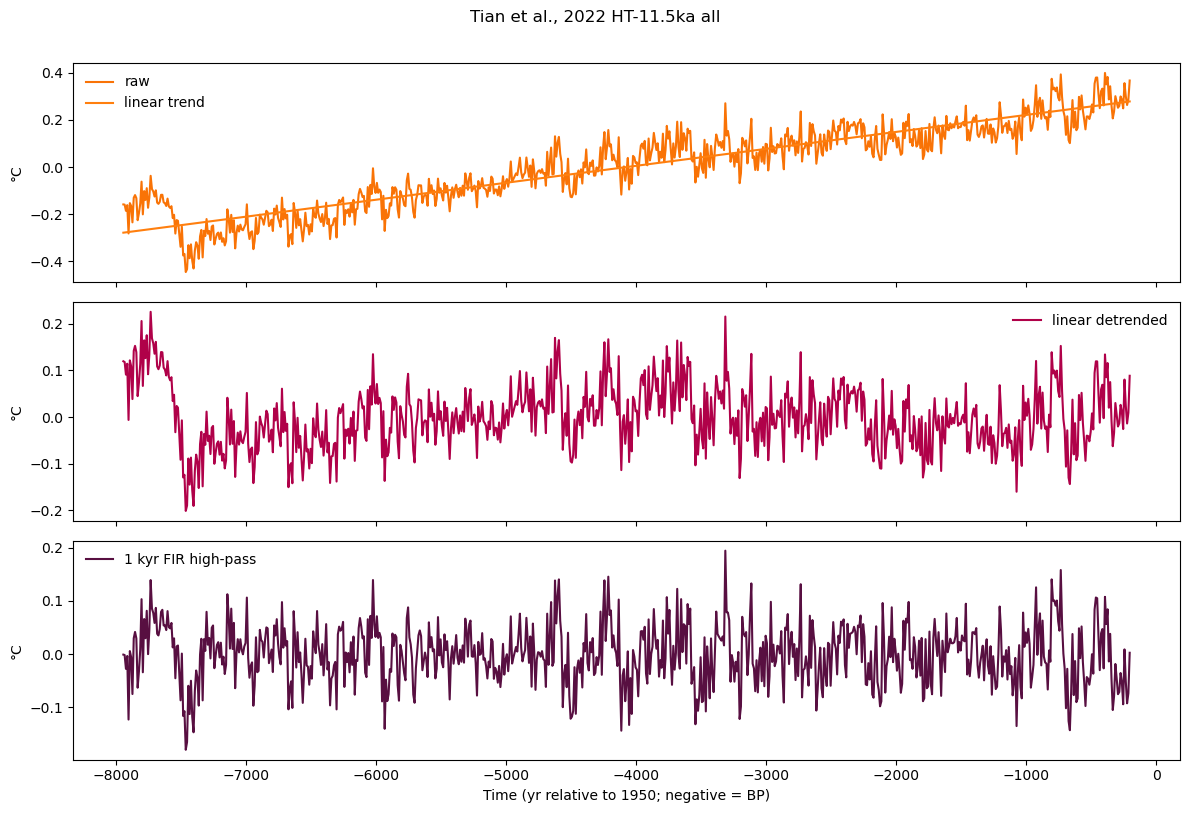

In [16]:
PLOT_RAW_VAR_ID = 'Tian22HT115kaALLGMST'

if PLOT_RAW_VAR_ID not in raw_var_objects:
    print('Run the real-treatment cell first, then rerun this plot cell.')
else:
    raw_object = raw_var_objects[PLOT_RAW_VAR_ID]
    linear_object = linear_var_objects[PLOT_RAW_VAR_ID]
    highpass_object = highpass_var_objects[PLOT_RAW_VAR_ID]
    time = raw_object.ts[raw_object.time_var]
    plot_colors = group_palette_triples[source_to_group[PLOT_RAW_VAR_ID.lower()]]

    figure, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    axes[0].plot(time, raw_object.ts[raw_object.col_name], color=plot_colors['raw'], label='raw')
    axes[0].plot(time, linear_trends[PLOT_RAW_VAR_ID], color='tab:orange', label='linear trend')
    axes[1].plot(time, linear_object.ts[linear_object.col_name], color=plot_colors['linearlydetrended'], label='linear detrended')
    axes[2].plot(time, highpass_object.ts[highpass_object.col_name], color=plot_colors['1kyr'], label='1 kyr FIR high-pass')

    for axis in axes:
        axis.legend(frameon=False)
        axis.set_ylabel(raw_object.unit or 'value')
    axes[-1].set_xlabel('Time (yr relative to 1950; negative = BP)')
    figure.suptitle(raw_object.var_label or PLOT_RAW_VAR_ID, y=1.01)
    figure.tight_layout()


For records that already sit close to stationary (e.g., ALLEY00), the treated
series barely differs from the raw one; for records carrying real macrostructure
(e.g., Döring22 GISP2), detrending or high-pass filtering visibly reshapes the
series.

## Generate surrogates from the treated series

This builds new phase-randomized surrogates directly from each treated real
series, the same way [Standardize Time Axes](1_setup__standardize_time_axes.ipynb) builds surrogates for
the raw series: `pyleo.SurrogateSeries`, 500 surrogates, phase-randomized method.

In [17]:
n_surrogates = 10
surrogate_method = 'phaseran'
surrogate_seed = 20260811

treated_surrogate_sets = {'linear': {}, 'highpass': {}}

np.random.seed(surrogate_seed)
treated_objects = {'linear': linear_var_objects, 'highpass': highpass_var_objects}
for treatment, objects in treated_objects.items():
    for raw_var_id, var_object in objects.items():
        surrogate_set = pyleo.SurrogateSeries(method=surrogate_method, number=n_surrogates)
        surrogate_set.from_series(var_object.ps)
        treated_surrogate_sets[treatment][raw_var_id] = surrogate_set


## Explicit save step (leave commented until reviewed)

The paths and column names below all come from the configured VarObjects. Uncomment
only after inspecting the treatment-ID table and the plot above. This writes the
real treated series to `master_data` and, if generated, the new treated surrogates
to `master_surrogates`.

In [18]:
for raw_var_id, target_ids in TREATMENT_CONFIG_IDS.items():
    for treatment, objects in {'linear': linear_var_objects, 'highpass': highpass_var_objects}.items():
        var_object = objects[raw_var_id]
        output_path = csv_path(var_object.real_data_dir_path, var_object.real_ts_csv)
        print(f'{raw_var_id} / {treatment}: {output_path.name}')
#         var_object.ts.to_csv(output_path, index=False)

for raw_var_id, target_ids in TREATMENT_CONFIG_IDS.items():
    for treatment, target_var_id in target_ids.items():
        surrogate_set = treated_surrogate_sets[treatment].get(raw_var_id)
        if surrogate_set is None:
            continue
        source_object = {'linear': linear_var_objects, 'highpass': highpass_var_objects}[treatment][raw_var_id]
        target_object = VarObject(None, target_var_id, PROJECT_ROOT)
        time = source_object.ts[source_object.time_var].to_numpy()
        surrogate_frame = pd.DataFrame({target_object.surr_ts_time: time})
        for number, surrogate in enumerate(surrogate_set.series_list, start=1):
            surrogate_frame[f'{target_object.surr_prefix}_{number}'] = surrogate.value
        output_path = csv_path(target_object.surr_data_dir_path, target_object.surr_ts_csv)
        print(f'{raw_var_id} / {treatment} surrogates: {output_path.name}')
#         surrogate_frame.to_csv(output_path, index=False)

Erb22daGMST / linear: Erb_2022_da_GMSTanom_decavg_temp__detrendedlinear.csv
Erb22daGMST / highpass: erb22_dagmst_temp__1kyrfir.csv
Wu18TSI / linear: Wu_2018_TSIanom_decavg__detrendedlinear.csv
Wu18TSI / highpass: wu18_tsianom_tsi__1kyrfir.csv
Vieira11TSI / linear: Vieira_2011_TSIanom_decavg_TSI__detrendedlinear.csv
Vieira11TSI / highpass: vieira11_tsianom_tsi__1kyrfir.csv
GISP2Alley00Tanom / linear: Alley_2000_GISP2_Tanom_decavg_temp__detrendedlinear.csv
GISP2Alley00Tanom / highpass: alley00_gisp2multiproxy_temp__1kyrfir.csv
Tian22HT115kaALLGMST / linear: tian22_ht115kaallgmst_temp_detrendedlinear.csv
Tian22HT115kaALLGMST / highpass: tian22_ht115kaallgmst_temp__1kyrfir.csv
GISP2Doering22T15N / linear: Doering_2022_A_T15N_goujon_decavg_temp__detrendedlinear.csv
GISP2Doering22T15N / highpass: doering22_gisp2t15n_temp__1kyrfir.csv
GISP2Martin24Tanom / linear: Martin_2024_GISP2_Tanom_decavg_temp__detrendedlinear.csv
GISP2Martin24Tanom / highpass: martin24_gisp2tanom_temp__1kyrfir.csv
NGRIP